# Error de Monte Carlo

Error real: la diferencia contra el valor exacto de Black-Scholes.

$$\text{error} = |V_{MC} - V_{BS}|$$

Solo se puede calcular porque este caso tiene fórmula cerrada.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm

S0, K, r, sigma, T = 100, 100, 0.05, 0.20, 1

d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

print(f"Black-Scholes = {bs:.6f}")

Black-Scholes = 10.450584


In [2]:
Ms = [10, 100, 1000, 10000, 100000, 1000000]
filas = []

for M in Ms:
    np.random.seed(42)
    Z = np.random.normal(0, 1, M)
    ST = S0*np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    precio = np.exp(-r*T)*np.maximum(ST - K, 0).mean()

    filas.append({
        "M": M,
        "Precio MC": precio,
        "Precio BS": bs,
        "Error absoluto": abs(precio - bs),
        "Error relativo (%)": abs(precio - bs)/bs*100
    })

tabla = pd.DataFrame(filas)
tabla

,M,Precio MC,Precio BS,Error absoluto,Error relativo (%)
0,10,14.020467,10.450584,3.569883,34.159654
1,100,8.159991,10.450584,2.290592,21.918321
2,1000,10.516569,10.450584,0.065986,0.631407
3,10000,10.450170,10.450584,0.000414,0.003958
4,100000,10.473892,10.450584,0.023308,0.223034
5,1000000,10.434158,10.450584,0.016426,0.157177


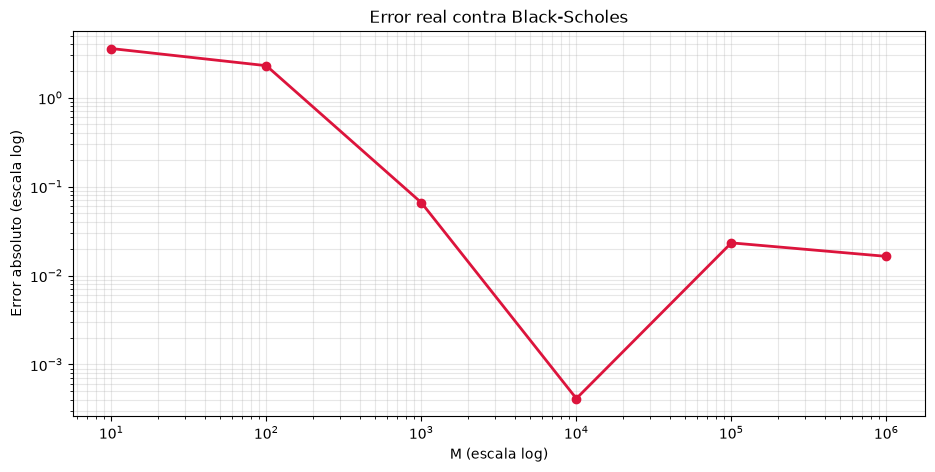

In [3]:
plt.figure(figsize=(11, 5))
plt.loglog(tabla["M"], tabla["Error absoluto"], "o-", lw=2, color="crimson")
plt.xlabel("M (escala log)"); plt.ylabel("Error absoluto (escala log)")
plt.title("Error real contra Black-Scholes")
plt.grid(alpha=.3, which="both")
plt.show()

## Error promedio sobre repeticiones

Una sola corrida no dice nada: su error es aleatorio. Para ver el
comportamiento real se repite el experimento 50 veces por cada M y se
estudia la **distribución** del error.

Se reporta el error medio y su desviación estándar.

In [4]:
R = 50
Ms = [10, 100, 1000, 10000]

np.random.seed(42)
filas = []
errores = {}

for M in Ms:
    errs = []
    for _ in range(R):
        Z = np.random.normal(0, 1, M)
        ST = S0*np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
        precio = np.exp(-r*T)*np.maximum(ST - K, 0).mean()
        errs.append(abs(precio - bs))

    errs = np.array(errs)
    errores[M] = errs
    filas.append({
        "M": M,
        "Error medio": errs.mean(),
        "Desv. est. del error": errs.std(ddof=1),
        "Error mínimo": errs.min(),
        "Error máximo": errs.max()
    })

tabla2 = pd.DataFrame(filas)
tabla2

,M,Error medio,Desv. est. del error,Error mínimo,Error máximo
0,10,3.862133,3.147614,0.165393,12.995283
1,100,1.268062,0.932144,0.034651,3.899381
2,1000,0.444050,0.320811,0.002900,1.284511
3,10000,0.129934,0.084818,0.009963,0.305598


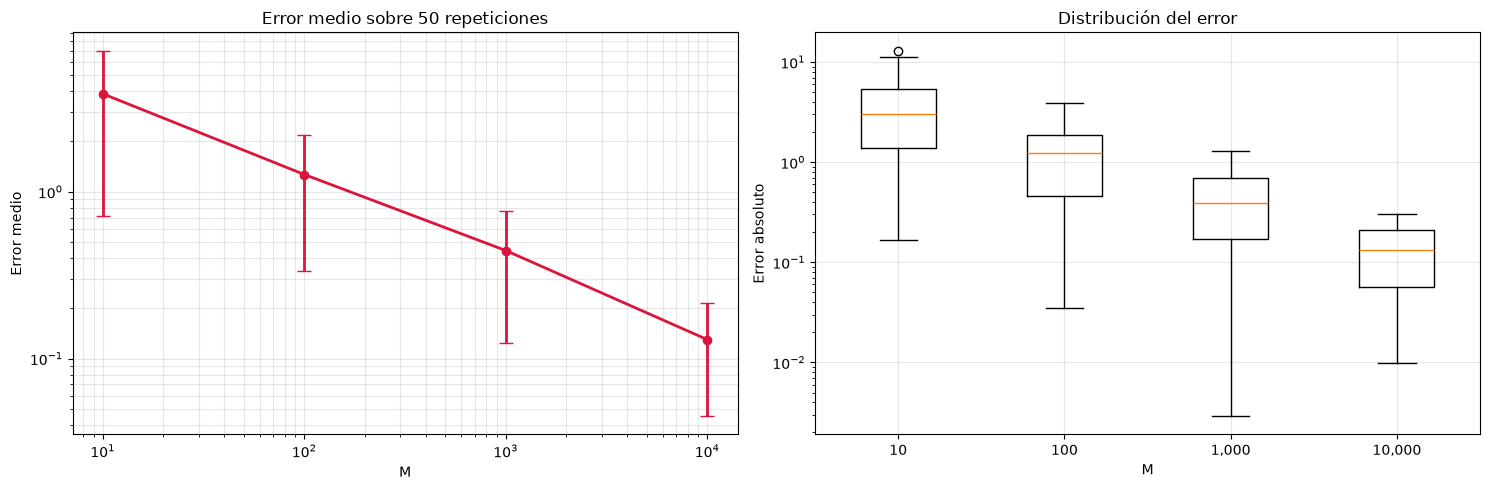

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(tabla2["M"], tabla2["Error medio"],
                 yerr=tabla2["Desv. est. del error"],
                 fmt="o-", capsize=5, lw=2, color="crimson")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("M"); axes[0].set_ylabel("Error medio")
axes[0].set_title(f"Error medio sobre {R} repeticiones")
axes[0].grid(alpha=.3, which="both")

axes[1].boxplot([errores[M] for M in Ms], tick_labels=[f"{M:,}" for M in Ms])
axes[1].set_yscale("log")
axes[1].set_xlabel("M"); axes[1].set_ylabel("Error absoluto")
axes[1].set_title("Distribución del error")
axes[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

---

# Conclusión

Con una sola corrida el error no baja en orden: con M = 10,000 salió 0.0004 y
con un millón 0.0164. Esa corrida tuvo suerte, nada más.

Al repetir 50 veces por cada M, el patrón aparece:

| M | Error medio | Desv. est. |
|---|---|---|
| 10 | 3.8621 | 3.1476 |
| 100 | 1.2681 | 0.9321 |
| 1,000 | 0.4440 | 0.3208 |
| 10,000 | 0.1299 | 0.0848 |

**La reducción real se ve cada dos renglones, no uno.** Comparando saltos de
M por 100: de 10 a 1,000 el error baja de 3.86 a 0.44, un factor de 8.7. De 100
a 10,000 baja de 1.27 a 0.13, un factor de 9.8. Ambos cerca de 10.

Eso es la tasa $O(M^{-1/2})$: hay que multiplicar M por **100** para ganar un
solo decimal. De un renglón al siguiente el error apenas se divide entre 3.

**Tres cosas que se concluyen:**

La convergencia es en promedio, no corrida por corrida. Una simulación
individual puede caer lejos del error típico.

La dispersión baja al mismo ritmo que el error. Con M = 10 el resultado podía
errarle por 13 pesos sobre un precio de 10.45; con M = 10,000 el peor caso fue
0.31.

El costo de la precisión es la limitación estructural del método, y la
motivación de las técnicas de reducción de varianza: el $\sqrt{M}$ no se puede
cambiar, la varianza del payoff sí.

**Y una limitación:** todo esto se pudo medir porque existe Black-Scholes. En
los casos donde Monte Carlo de verdad hace falta no hay con qué comparar, y ahí
se necesita el error estándar.